# 1. Analyze data
Dataset:
- Image size: 64 × 64
- Num of timesteps: 2122
- 10 actions (forward, left, back, right, jump, sneak, sprint, attack, horizontal camera change, vertical camera change)
- Actions Dimensions (2122, )
- Camera Dimensions (2122, 2)

ex:
```
$action$forward = [1, 1, 1, ..., 0, 0, 0]
$action$left = [1, 0, 1, ..., 0, 1, 0]
```

We must translate this a (2122, 10) dimension vector:
```
timestamp0 = [1, 0, 0, 0, 0, 0, 0, 0, -0.15, 0.15]
...
```


In [28]:
import cv2
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import concurrent.futures
import os
import time
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import stable_worldmodel as swm
import h5py


In [29]:


data_path = Path('data/MineRLTreechop-v0')

# load action samples
sample_dirs = sorted([p for p in data_path.iterdir() if p.is_dir()])

# load first sample
if sample_dirs:
    npz = np.load(sample_dirs[0] / 'rendered.npz')
    print(npz)
    # extract actions as a dictionary
    action_keys = [k for k in npz.keys() if k.startswith('action')]
    actions = {k: npz[k] for k in action_keys}

    print(f"actions: {actions}")
else:
    print(f"no actions for {sample_dirs[0]}")

NpzFile 'data/MineRLTreechop-v0/v3_absolute_grape_changeling-15_10696-12887/rendered.npz' with keys: reward, action$forward, action$left, action$back, action$right...
actions: {'action$forward': array([1, 1, 1, ..., 0, 0, 0], shape=(2122,)), 'action$left': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$back': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$right': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$jump': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$sneak': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$sprint': array([0, 0, 0, ..., 0, 0, 0], shape=(2122,)), 'action$attack': array([0, 0, 0, ..., 1, 1, 1], shape=(2122,)), 'action$camera': array([[-0.14999998,  0.15000153],
       [-0.        ,  0.15000153],
       [ 0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ],
       [ 1.3500004 , -0.75      ]], shape=(2122, 2), dtype=float32)}


# 2. Preprocess for LeWM
 - Decode frames from recording
 - Action stacking: organize data as timestamp arrays of actions

 * Note the number of frames slightly mismatches with the number of timestamps.

In [ ]:

# ======= Helpers =======
def load_video_frames(video_path: str):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)

    frames = []
    f_times = []
    f_index = 0

    while True:
        # read each frame sequentially
        # ret is a boolean indicating if retrieval was successful
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
        # cv2.imshow('frame_bgr', frame_rgb)
        f_times.append(f_index / fps)
        f_index += 1

    print(f"fps: {fps}")
    print(f"num frames: {len(frames)}")
    print(f"frame times: {f_times[:20]}")

    return frames


def process_actions(s, action_arrays, action_keys):
    actions_np = np.stack([action_arrays[k] for k in action_keys], axis=1).astype(np.float32)

    print("actions", actions_np[:20])
    print(f"num of action timesteps: {len(actions_np)}")
    print("location save", s / 'actions.npy')

    np.save(s / 'actions.npy', actions_np)


def process_camera(s, action_arrays):
    camera_np = np.asarray(action_arrays['action$camera']).astype(np.float32)

    print("camera", camera_np[:20])
    print(f"num of camera timesteps: {len(camera_np)}")
    print("location save", s / 'camera.npy')

    np.save(s / 'camera.npy', camera_np)


def process_sample(s):
    npz = np.load(s / 'rendered.npz')
    video = load_video_frames(s / 'recording.mp4')
    with open(s / 'metadata.json', 'r') as f:
        metadata = json.load(f)

    # Load actions
    action_keys = [k for k in npz.keys() if k.startswith('action')]
    action_arrays = {k: npz[k] for k in action_keys}
    action_keys = [k for k in action_keys if k != 'action$camera']

    if action_keys:
        process_actions(s, action_arrays, action_keys)

    if 'action$camera' in action_arrays:
        process_camera(s, action_arrays)


# ======= Load all samples in parallel =======
start_time = time.perf_counter()

with concurrent.futures.ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # map futures to each data sample
    future_to_sample = {executor.submit(process_sample, s): s for s in sample_dirs}
    for future in concurrent.futures.as_completed(future_to_sample):
        s = future_to_sample[future] # map completed processing output to original sample
        try:
            data = future.result()
        except Exception as e:
            print(f"error {e}")
end_time = time.perf_counter()
print(f"total wall clock {end_time-start_time} seconds")



action [1. 1. 0. 0. 0. 0. 0. 1.]


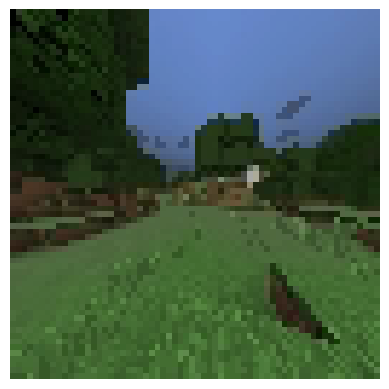

In [ ]:
# get the action at timestamp 
sample_dir = Path('data/MineRLTreechop-v0/v3_absolute_grape_changeling-7_14600-16079')
t = 23

# get action
actions = np.load(sample_dir / 'actions.npy')
print("action", actions[t])

# get video frame
cap=cv2.VideoCapture(str(sample_dir / 'recording.mp4'))
cap.set(cv2.CAP_PROP_POS_FRAMES, t)
ret, frame_bgr = cap.read()
cap.release()
if not ret:
    print(f"Could not read frame {t}")
else:
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

### Covert to HDHF format
HDHF is the standard way for organizing hierarchical and multidimensional data.
- Frames - unsigned 8 int array [T, 64, 64, C]
- Actions - 32 int float array [T, 10]
where T = timesteps and C = colors (RGB)

In [ ]:
def create_training_data(output_path:str, sample_dirs:str):
        # use to find the global positioning of the current episode
        global_ptr = 0

        # initialize output path
        with h5py.File(output_path, 'w') as f:
                # Observations: (T, 64, 64, 3)
                f.create_dataset('pixels', shape=(0, 64, 64, 3), maxshape=(None, 64, 64, 3), dtype='uint8', chunks=(1, 64, 64, 3))
                # Actions: (T, 10) 
                f.create_dataset('action', shape=(0, 10), maxshape=(None, 10), dtype='float32', chunks=(1, 10))
                # Metadata for indexing
                f.create_dataset('ep_len', shape=(0,), maxshape=(None,), dtype='int32')
                f.create_dataset('ep_offset', shape=(0,), maxshape=(None,), dtype='int64')

                # process samples
                for s in sample_dirs:
                        # 1. load mp4 into numpy array
                        frames = load_video_frames(s / "recording.mp4")
                        
                        # 2. combine actions.npy and camera.npy into one action list
                        actions = np.load(s / "actions.npy")
                        camera = np.load(s / "camera.npy")
                        actions_combined = np.concatenate([actions, camera], axis=-1).astype(np.float32)
                        print("actions combined", actions_combined[:5])

                        # the video often has more frames than the actions. if there are leftover
                        # frames, we truncate the episode length to avoid extraneous frames with no action labels
                        ep_len = min(len(frames), len(actions_combined))
                        # slice actions and frames to align with length
                        actions_hat = actions_combined[:ep_len]
                        frames_hat = np.array(frames[:ep_len])
                        
                        # 3. append to hdf5
                        f['pixels'].resize((global_ptr + ep_len, 64, 64, 3))
                        f['pixels'][global_ptr : global_ptr + ep_len] = frames_hat
                        
                        f['action'].resize((global_ptr + ep_len, 10))
                        f['action'][global_ptr : global_ptr + ep_len] = actions_hat
                        
                        curr_ep_idx = len(f['ep_len'])
                        f['ep_len'].resize((curr_ep_idx + 1,))
                        f['ep_offset'].resize((curr_ep_idx + 1,))
                        f['ep_len'][curr_ep_idx] = ep_len
                        f['ep_offset'][curr_ep_idx] = global_ptr
                        
                        global_ptr += ep_len
                        print(f"Processed {s}: {ep_len} frames")

# run full pipeline
create_training_data('mineRL_training.h5', sample_dirs)

fps: 20.0
num frames: 2192
frame times: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
actions combined [[ 1.          0.          0.          0.          0.          0.
   0.          0.         -0.14999998  0.15000153]
 [ 1.          0.          0.          0.          0.          0.
   0.          0.         -0.          0.15000153]
 [ 1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 1.          0.          0.          0.          0.          0.
   0.          0.          0.44999993 -1.2000046 ]]


TypeError: object of type 'NoneType' has no len()